
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 3
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

- Senoidal de frecuencia $f_{0}=k_{0}∗f_{S}/N=k_{0}.Δf$
- potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

**a)** Sea k0
- $\frac{N}{4}$
- $\frac{N}{4} + 0.25$
- $\frac{N}{4} + 0.5$
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $Δf$. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

**b)** Verificar la potencia unitaria de cada PSD, puede usar la **identidad de Parseval**. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

**c)** Repetir el experimento mediante la técnica de *zero padding*. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $Δf$ de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

# Resolución item a)

En esta sección, se analiza el comportamiento de la Densidad Espectral de Potencia (PSD) frente a variaciones en la frecuencia fundamental de una señal senoidal. El objetivo principal es observar cómo la relación entre la frecuencia de la señal ($f_0$) y la resolución espectral del sistema ($\Delta_f$) determina la presencia o ausencia de desparramo espectral (leakage).

Para garantizar la consistencia en la comparación, se definieron los siguientes parámetros globales:
- Frecuencia de muestreo ($f_s$): 1000 Hz.
- Número de muestras ($N$): 100.
- Resolución espectral: $\Delta_f = \frac{f_s}{N} = 10\text{ Hz}$.
- Amplitud: $A = \sqrt{2}$, seleccionada para obtener una señal de potencia unitaria.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Función para sintetizar señales senoidales
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    
    tt = np.linspace(0, (nn-1)*ts, nn)
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    
    return tt, xx

fs = 1000 # Frecuencia de muestreo
N = 100 # Numero de muestras
vmax = np.sqrt(2)
delta_f = fs / N

pos_freqs = np.arange(N//2) * delta_f # Eje de frecuencia en común

A continuación, se generan tres señales variando el coeficiente $k_0$, evaluando los casos de sintonía perfecta ($k_0 = N/4$) y desintonía ($+0.25$ y $+0.5$).

**Caso $k_{0} = \frac{N}{4}$**

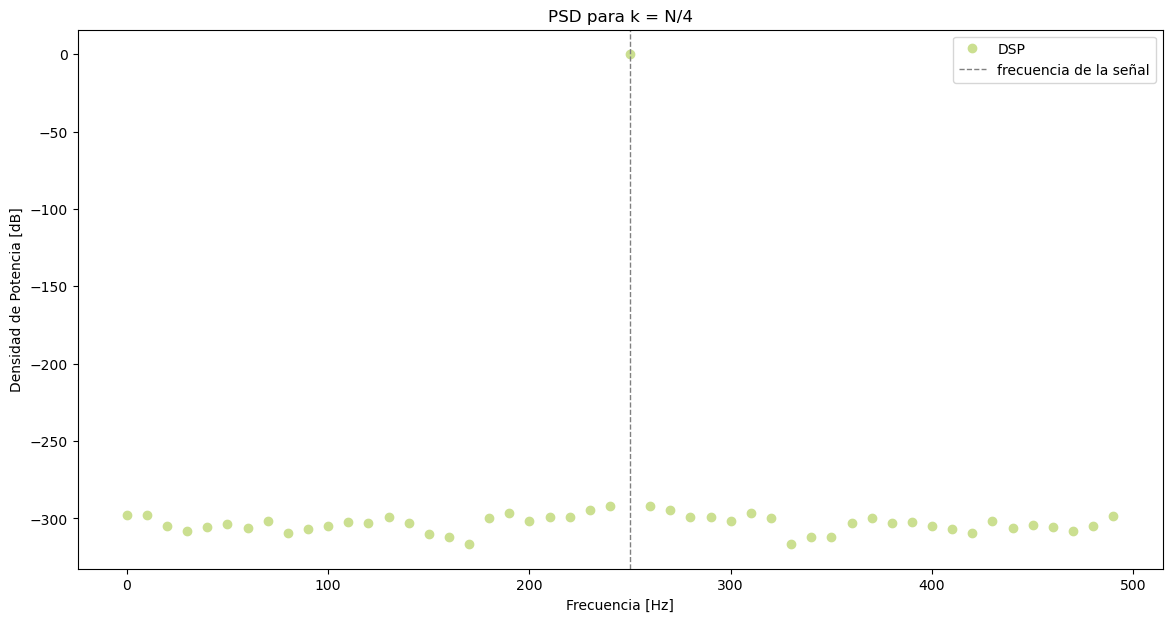

In [53]:
k = N/4

f0 = k * (fs / N)
tt, xx = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)

XX = np.fft.fft(xx) / N
psd_XX = 10 * np.log10(2 * np.abs(XX[:N//2])**2)

plt.figure(figsize=(14, 7))
plt.plot(pos_freqs, psd_XX, 'o', color='#CBDF90', label='DSP')
plt.title('PSD para k = N/4')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.axvline(x=250, color='grey', linestyle='--', linewidth=1, label = 'frecuencia de la señal')
plt.legend(loc='upper right')
plt.show()

Dado que $k_0$ es un número entero ($N/4$), la frecuencia de la señal senoidal coincide exactamente con uno de los puntos de muestreo en el dominio de la frecuencia (bin) de la DFT. Esto significa que la señal completa un número entero de ciclos dentro de la ventana de observación de $N$ muestras.

En el gráfico se observa un único pico pronunciado en 250 Hz, mientras que el resto de los coeficientes tienen valores extremadamente bajos (cercanos a -300 dB). Esto indica que no hay desparramo espectral. Toda la potencia de la señal está concentrada en un solo bin, lo que confirma que la periodicidad de la señal es coherente con la longitud de la ventana.

**Casos $k_{0} = \frac{N}{4} + 0.25$ y $k_{0} = \frac{N}{4} + 0.5$**

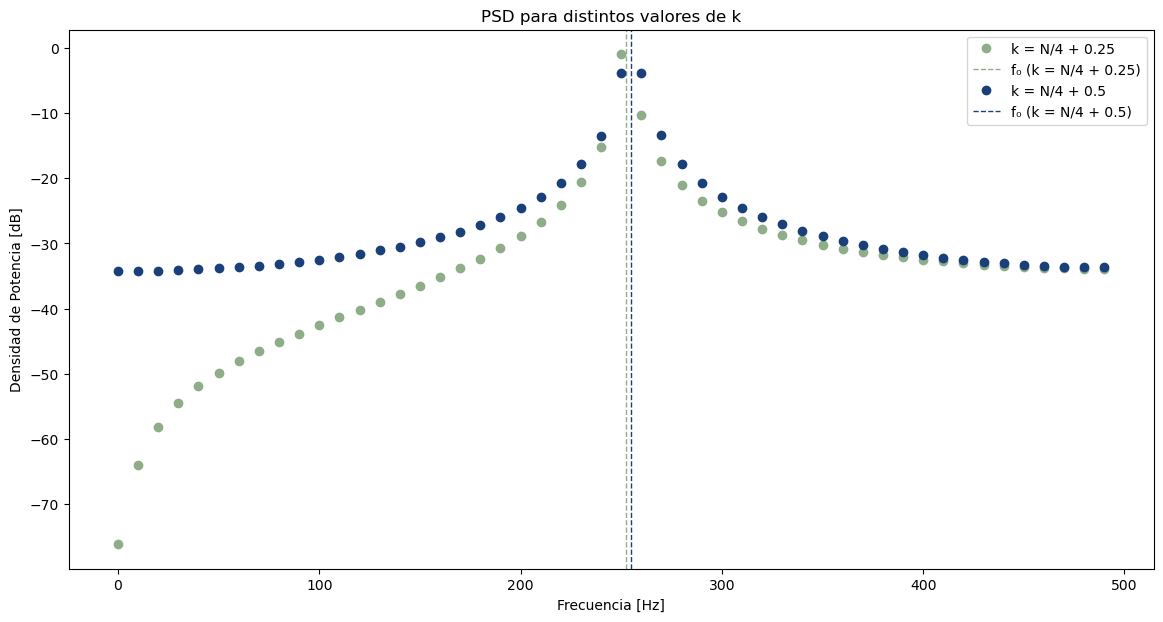

In [62]:

casos = [
    {'k_offset': 0.25, 'color': '#8FAD88', 'label': 'k = N/4 + 0.25'},
    {'k_offset': 0.5,  'color': '#1B4079', 'label': 'k = N/4 + 0.5'},
]

plt.figure(figsize=(14, 7))

for caso in casos:
    k = N/4 + caso['k_offset']
    f0 = k * (fs / N)
    tt, xx = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)
    XX = np.fft.fft(xx) / N
    psd_XX = 10 * np.log10(2 * np.abs(XX[:N//2])**2)

    plt.plot(pos_freqs, psd_XX, 'o', color=caso['color'], label=caso['label'])
    plt.axvline(x=f0, color=caso['color'], linestyle='--', linewidth=1, label = f"f₀ ({caso['label']})")

plt.title('PSD para distintos valores de k')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend()
plt.show()

A diferencia del primer caso, aquí la frecuencia de la señal ($f_0$) no coincide exactamente con un bin de la DFT. Esto rompe la periodicidad implícita de la DFT, provocando que la energía de la señal se "desparrame" hacia los bins vecinos. El como se desparrama esta potencia, es distinto en cada caso

En $k_0 = N/4 + 0.25$, el pico está más cerca de un bin que de otro, por lo que el desparramo resulta asimétrico.

En $k_0 = N/4 + 0.5$, la frecuencia está exactamente en el medio de dos bins. Es por eso que se observan dos puntos con la misma amplitud máxima, y un desparramo simétrico.

En el primer gráfico el pico llegaba a 0 dB. En estos, el punto más alto está por debajo de 0 dB. No es que la señal tenga menos potencia, sino que la DFT está "muestreando" la forma de onda de la ventana (el lóbulo principal) fuera de su centro (esto se verá mejor en el item c).

# Resolución item b)

La Identidad de Parseval establece la equivalencia de la energía (o potencia) de una señal entre el dominio del tiempo y el dominio de la frecuencia. En términos prácticos para la DFT, nos indica que la suma de las potencias de cada muestra en el tiempo debe ser igual a la suma de las potencias de cada bin espectral (ajustada por el factor de escala $1/N$).

El objetivo de esta sección es verificar que, independientemente del nivel de desparramo espectral observado en el punto anterior, la potencia total de la señal se mantiene constante y coherente entre ambos dominios, cumpliendo con la ley de conservación de la energía.

In [18]:
print("VERIFICACIÓN IDENTIDAD DE PARSEVAL")

k_values = [N/4, N/4 + 0.25, N/4 + 0.5]
labels = ['k = N/4', 'k = N/4 + 0.25', 'k = N/4 + 0.5']

for k, label in zip(k_values, labels):
    f0 = k * (fs / N)
    tt, xx = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)
    
    # Potencia = varianza (por el dc=0)
    potencia_tiempo = np.mean(xx**2)

    XX = np.fft.fft(xx) / N 
    # Potencia frecuencia 
    potencia_freq = N * np.sum(np.abs(XX)**2)
    
    # solo frecuencias positivas
    XX_raw = np.fft.fft(xx)
    potencia_parseval = (1/N**2) * (
        np.abs(XX_raw[0])**2 +
        2 * np.sum(np.abs(XX_raw[1:N//2])**2) +
        np.abs(XX_raw[N//2])**2
    )
    
    print(f"\n{label}  →  f0 = {f0:.2f} Hz")
    print(f"  Potencia dominio tiempo  : {potencia_tiempo:.6f}")
    print(f"  Parseval (todos los bins): {potencia_freq/N:.6f}")   
    print(f"  Parseval (frec. pos.)    : {potencia_parseval:.6f}")
    print(f"  Potencia teórica (vmax²/2): {vmax**2/2:.6f}")

VERIFICACIÓN IDENTIDAD DE PARSEVAL

k = N/4  →  f0 = 250.00 Hz
  Potencia dominio tiempo  : 1.000000
  Parseval (todos los bins): 1.000000
  Parseval (frec. pos.)    : 1.000000
  Potencia teórica (vmax²/2): 1.000000

k = N/4 + 0.25  →  f0 = 252.50 Hz
  Potencia dominio tiempo  : 0.990000
  Parseval (todos los bins): 0.990000
  Parseval (frec. pos.)    : 0.990000
  Potencia teórica (vmax²/2): 1.000000

k = N/4 + 0.5  →  f0 = 255.00 Hz
  Potencia dominio tiempo  : 1.000000
  Parseval (todos los bins): 1.000000
  Parseval (frec. pos.)    : 1.000000
  Potencia teórica (vmax²/2): 1.000000


En los tres casos evaluados ($k_0 = N/4$, $N/4 + 0.25$ y $N/4 + 0.5$), el valor de la Potencia en el dominio del tiempo coincide exactamente con el valor calculado mediante Parseval (tanto usando todos los bins como solo las frecuencias positivas). Esto confirma que la implementación de la DFT y el cálculo de la densidad espectral son correctos.

Es fundamental notar que, aunque en el ítem (a) vimos que para $k_0 = N/4 + 0.5$ la energía se distribuía entre muchos bins (leakage), la suma total de esa energía sigue siendo igual a $1$. Esto demuestra que el desparramo espectral no crea ni destruye energía, sino que simplemente la redistribuye a lo largo del espectro debido al efecto de ventaneo.

En el caso $k_0 = N/4 + 0.25$ se observa que la potencia real de la señal es de $0.99$, ligeramente inferior a la potencia teórica de $1$. La potencia teórica ($V_{max}^2/2$) asume una señal continua o un número entero de ciclos. Cuando la señal no es periódica respecto a la ventana de observación (como en este caso de desintonía), el promedio cuadrático de las $N$ muestras discretas puede variar levemente dependiendo de qué parte de la sinusoide se está capturando. Sin embargo, lo importante es que Parseval sigue reflejando fielmente la potencia de esas muestras específicas.

En resumen, la identidad de Parseval actúa como un "balance de energía". Mientras que en el caso ideal ($k_0 = N/4$) toda la potencia se concentra en un solo bin, en los casos desintonizados esa misma potencia se reparte, validando la consistencia matemática de la transformación de Fourier a pesar de las limitaciones de resolución espectral.

# Resolución item C)

La técnica de Zero Padding consiste en concatenar un número determinado de ceros al final de la secuencia temporal original antes de calcular la DFT. En este experimento, se aumentó la longitud de la señal de $N$ a $10N$ muestras ($N_{zp} = 1000$).

Es fundamental aclarar que esta técnica no mejora la resolución espectral real (la capacidad de distinguir dos frecuencias cercanas), la cual sigue dependiendo únicamente de la ventana de tiempo original. Sin embargo, el zero padding aumenta la densidad de muestreo en el dominio de la frecuencia, reduciendo el $\Delta_f$ ficticiamente. Esto permite interpolar el espectro y observar la forma continua de la Transformada de Fourier de Tiempo Discreto (DTFT) de la señal ventaneada.


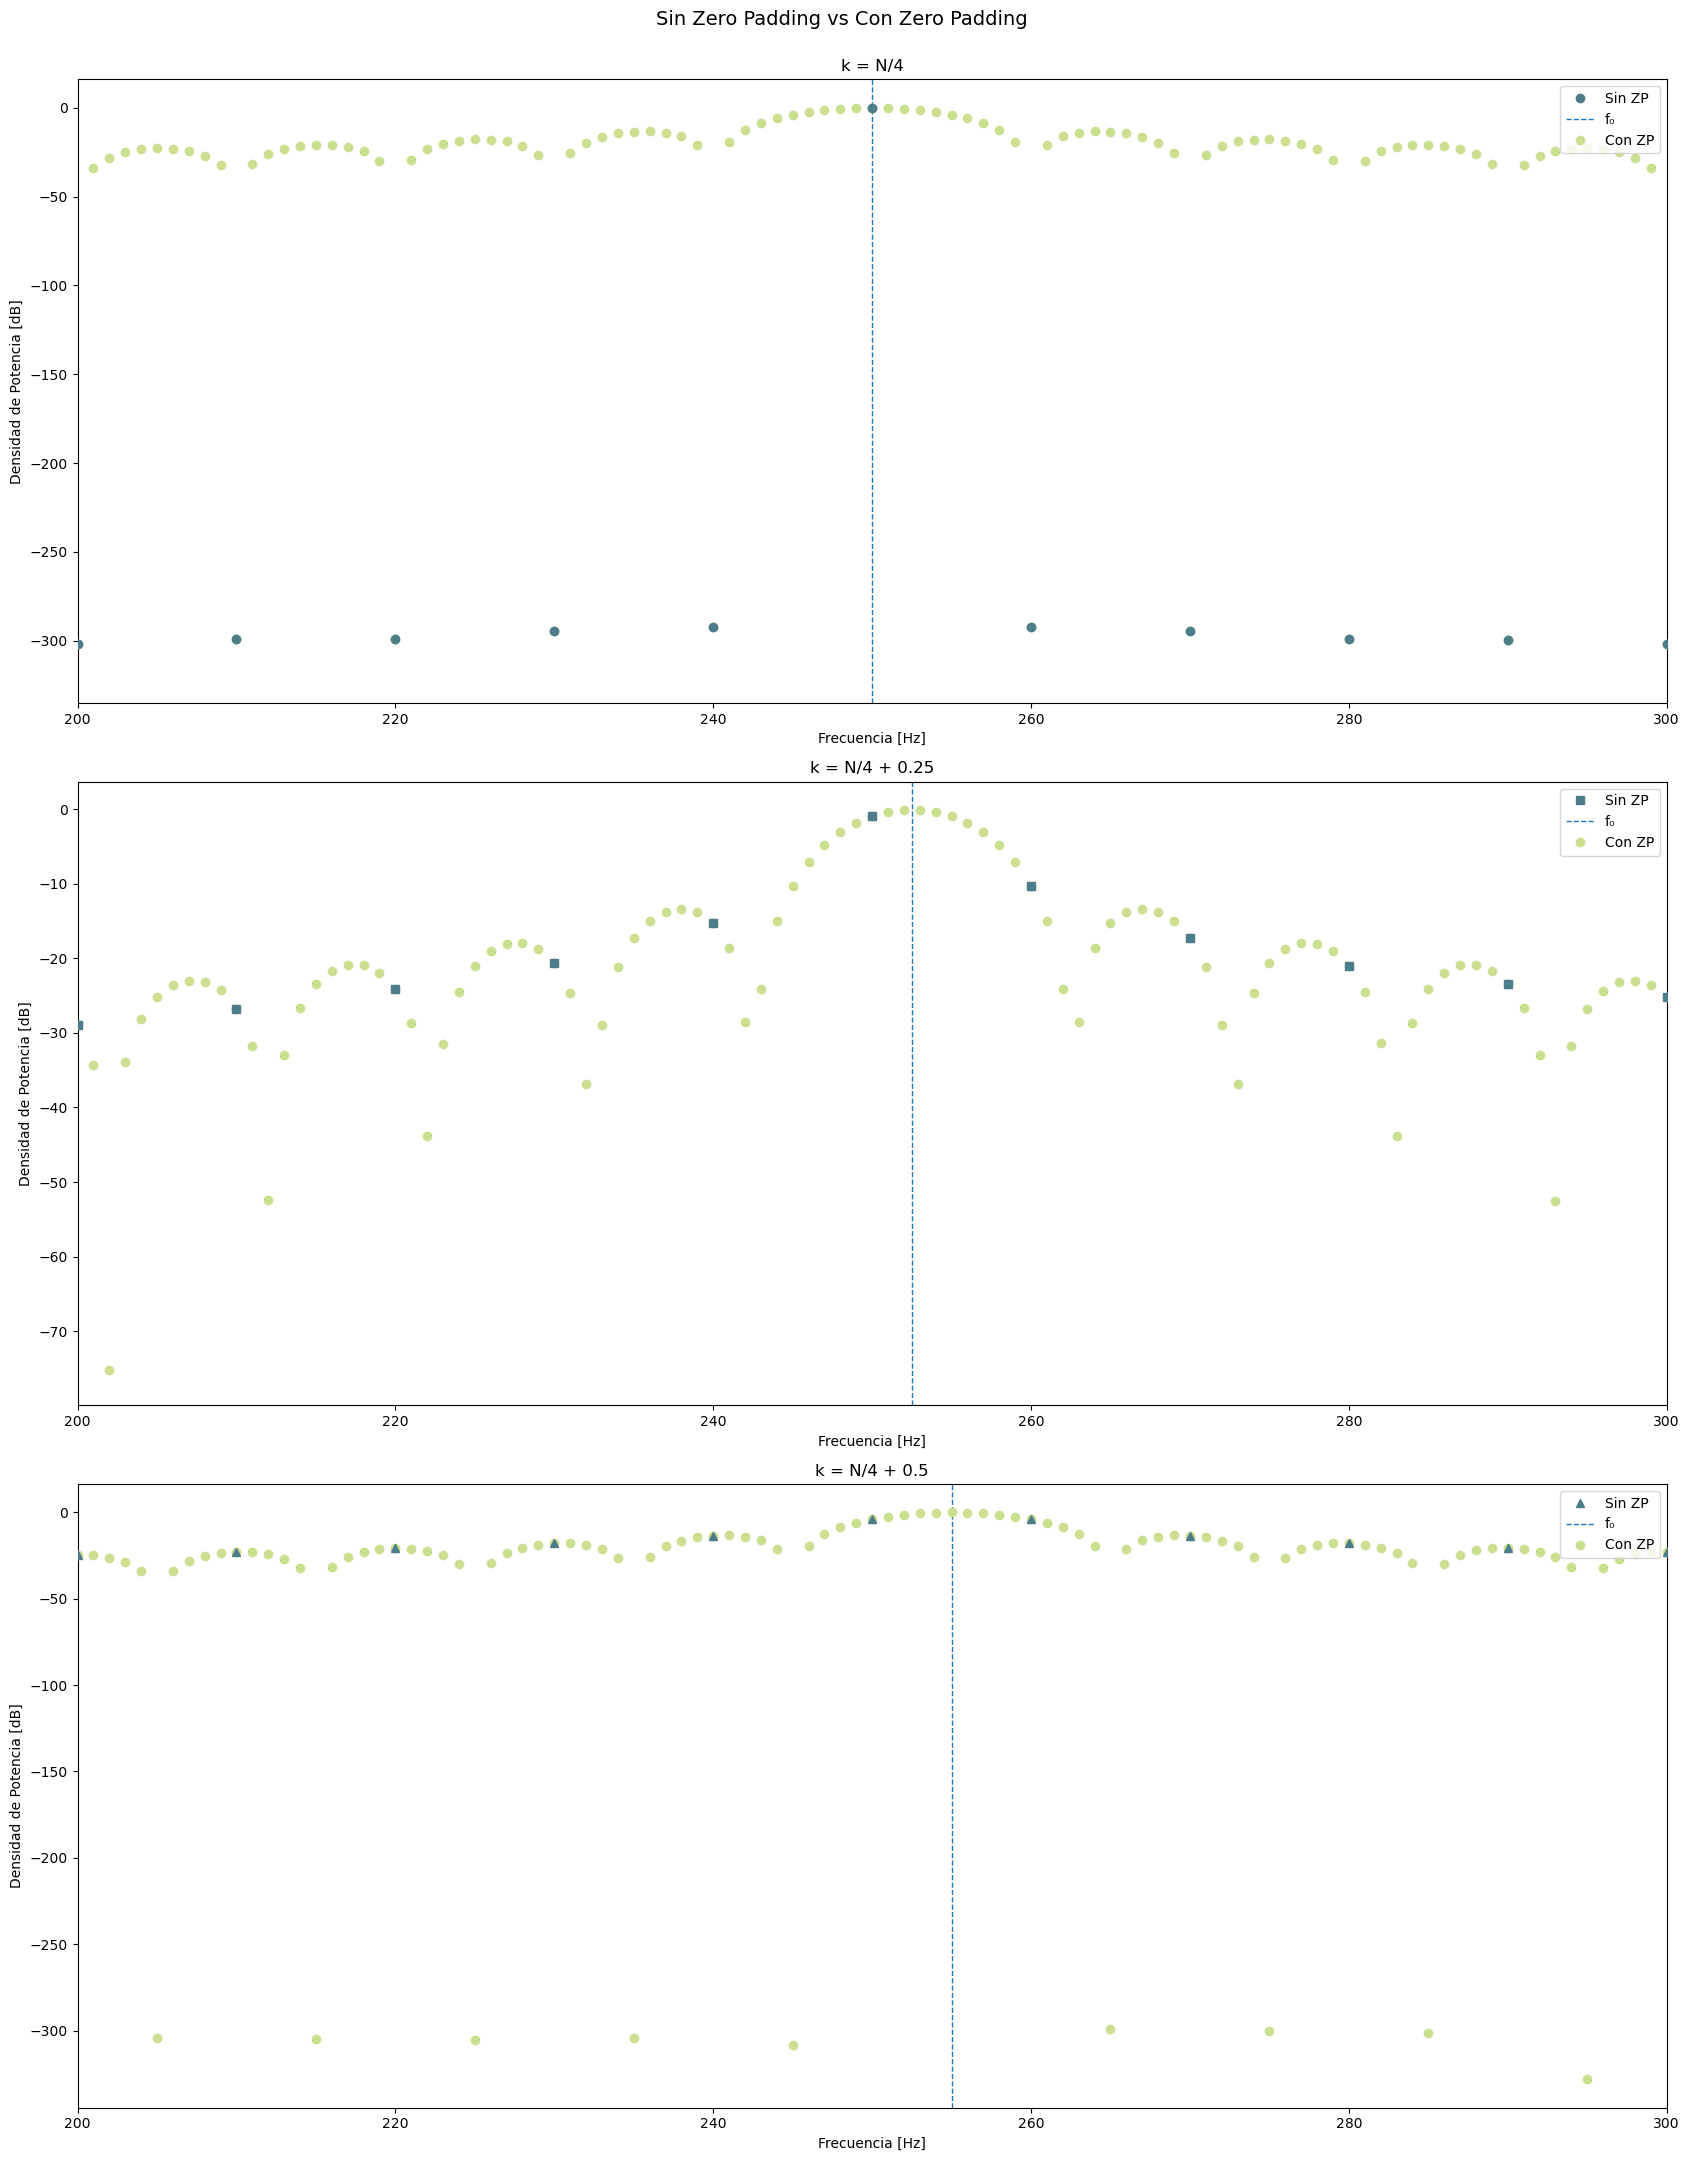

In [64]:
k_values = [N/4, N/4 + 0.25, N/4 + 0.5]
labels = ['k = N/4', 'k = N/4 + 0.25', 'k = N/4 + 0.5']

N_zp = N + (9 * N) # el N para el zero padding pedido por la consigna
delta_f_zp = fs / N_zp

fig1, axes = plt.subplots(3, 1, figsize=(17, 22))
fig1.suptitle('Sin Zero Padding vs Con Zero Padding \n\n', fontsize=14)

for ax, k, label, marker in zip(axes, k_values, labels, markers):
    f0 = k * (fs / N)
    tt, xx = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)

    # Sin zero padding
    pos_freqs = np.arange(N//2) * delta_f
    XX = np.fft.fft(xx) / N
    psd_XX = 10 * np.log10(2 * np.abs(XX[:N//2])**2)
    ax.plot(pos_freqs, psd_XX, marker, label='Sin ZP', color='#4D7C8A', zorder=5)
    ax.axvline(x=f0, linestyle='--', linewidth=1, label = "f₀")


    # Con zero padding
    pos_freqs_zp = np.arange(N_zp//2) * delta_f_zp
    xx_zp = np.concatenate([xx, np.zeros(N_zp - N)])
    XX_zp = np.fft.fft(xx_zp) / N
    psd_XX_zp = 10 * np.log10(2 * np.abs(XX_zp[:N_zp//2])**2)
    ax.plot(pos_freqs_zp, psd_XX_zp, 'o', label='Con ZP', color='#CBDF90', zorder=3)

    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Densidad de Potencia [dB]')
    ax.set_title(label)
    ax.set_xlim(200, 300)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Cuando la frecuencia de la señal $f_0$ no es un múltiplo exacto de la resolución espectral $\Delta_f$ (es decir, $k_0$ no es entero), se produce el fenómeno conocido como desparramo espectral. Matemáticamente, lo que observamos en la DFT es un muestreo de la Transformada de Fourier de Tiempo Discreto (DTFT) de la señal ventaneada. Al usar una ventana rectangular de longitud $N$, la DTFT de una senoidal no es un impulso de Dirac, sino una función sinc ($\frac{\sin(x)}{x}$) centrada en $f_0$ (kernel de Dirichlet).

El zero padding permite visualizar que ese "desparramo" observado no es ruido aleatorio, sino la estructura de los lóbulos laterales de la función sinc asociada a la ventana rectangular. Los puntos verdes claros 'dibujan' la curva continua que une a los puntos azules.

 - Caso $k_0 = N/4 + 0.25$ (Desintonía Leve)
En este escenario, el pico de la función sinc se encuentra desplazado un $25\%$ respecto al bin más cercano. Debido a este desplazamiento, las muestras de la DFT (los "bins") capturan puntos de la función sinc que no son simétricos respecto al lóbulo principal. Esto se traduce visualmente en una caída de energía más lenta hacia un lado del espectro que hacia el otro.
El bin de mayor valor ya no coincide con el máximo de la sinc, lo que explica por qué el pico en el gráfico no alcanza los $0\text{ dB}$.

- Caso $k_0 = N/4 + 0.5$ (Máxima Desintonía)
Este es el caso crítico de desintonía, donde la frecuencia de la señal cae exactamente en el punto medio entre dos bins contiguos. Se ve la simetría perfecta de los lóbulos secundarios y cómo el máximo de la Sinc cae justo a mitad de camino entre dos muestras de la DFT original, provocando que ambos puntos marquen la misma amplitud atenuada. 

# Conclusiones generales

A partir del análisis teórico y experimental desarrollado a lo largo de este trabajo, se consolidan las siguientes conclusiones sobre las propiedades y limitaciones de la Transformada Discreta de Fourier (DFT).

Se demostró que el fenómeno de desparramo espectral no implica una pérdida de energía, sino que es la consecuencia matemática inevitable de recortar una señal en el tiempo. Al aplicar una ventana rectangular de longitud $N$ (implicita al hacer DFT), el espectro de la señal se convoluciona con la transformada de dicha ventana (un kernel de Dirichlet o función Sinc). Cuando la frecuencia de la señal ($f_0$) no coincide con un múltiplo exacto de la resolución espectral ($\Delta f$), la DFT muestrea fuera de los cruces por cero de esta Sinc, exponiendo sus lóbulos secundarios en el espectro visualizado.
  
Mediante la verificación numérica, se comprobó la validez de la Identidad de Parseval como un "balance de energía" infalible. El desparramo espectral redistribuye la potencia entre los distintos bins, pero la potencia total se conserva idéntica entre el dominio del tiempo y el de la frecuencia. Asimismo, se evidenció que cuando la señal no es periódica respecto a la ventana de observación (como en el caso de desintonía de $+0.25$), el truncamiento de ciclos completos afecta levemente el valor de la potencia real calculada en el tiempo (reduciéndose a $0.99$ en lugar de $1.00$), lo cual es fielmente reflejado por Parseval en ambos dominios.

Se constató de forma gráfica que añadir ceros al final de la secuencia temporal (usar zero-padding) no mejora la resolución física del sistema (la capacidad de distinguir frecuencias cercanas, la cual depende exclusivamente de $N$). Sin embargo, funciona como un método de interpolación ideal en el dominio de la frecuencia al disminuir de manera ficticia el espaciado de los bins ($\Delta f$). Esto permite "revelar" la estructura continua de la DTFT de la señal ventaneada, permitiendo localizar con exactitud el pico de amplitud real de la sinusoide.